In [1]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import MagmaChamber, GlobalSystemThreshold

In [51]:
# Set Maxwell times
t_b = 1e11
t_d = 5e10
K_crust = 10e9
G_crust = 10e9
K_f = 10e9
rho0 = 2500

# Constant viscosity assumption
mu0 = 1e6
# Effective hydraulic radius
r_hydr = 5

# Fix total volume
total_vol = (4/3)*np.pi*1000.0**3
# Fix mass injection
mass_inj = total_vol * rho0 * 0.001

# Network parameters
x_scale = 40000.0
y_scale = 0.0
z_scale = 40000.0 # Depth

In [52]:
V_total = 1e9
N_x_range:int = np.arange(1,30,1)
problem_list = [None for _ in N_x_range]

for i, N_x in enumerate(N_x_range):
  # Set square grid
  N_z = N_x
  # Set planar geometry (y-scale = 0)
  y_scale = 0.0
  # Compute total number of chambers in grid
  N_chamber = N_x * N_z
  # Generate chamber coordinates
  z_axis = np.linspace(0, z_scale, N_z)
  # Shuffle index so center node starts
  _x1 = np.arange(N_x//2-1, -1, -1)
  _x2 = np.arange(N_x//2, N_x, )
  _ind = np.empty((N_x,), dtype=int)
  _ind[::2] = _x2
  _ind[1::2] = _x1
  x_axis = np.linspace(0, x_scale, N_x)[_ind]

  mg_x, mg_z = np.meshgrid(x_axis, z_axis)
  x_nodes = mg_x.ravel()
  y_nodes = y_scale * np.zeros((N_chamber,))
  z_nodes = mg_z.ravel()

  # Swap -1 index with the center node at the top layer
  x_nodes[-1], x_nodes[-N_x] = x_nodes[-N_x], x_nodes[-1]
  z_nodes[-1], z_nodes[-N_x] = z_nodes[-N_x], z_nodes[-1]

  if N_z == 1:
    z_nodes[:] = 0.5 * z_scale

  # Split volume among constituents
  V_nodes = np.full((N_chamber,), V_total / N_chamber)

  list_nodes = [MagmaChamber(x=x, y=y, z=z,
                      p_setting=None, T_setting=1200, V_setting=V)
  for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]
  problem_list[i] = list_nodes

In [53]:
def setup_system(list_nodes, dpdx_crit):
  # Set up for timestepping later
  global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                    r_hydr=r_hydr, mu0=mu0, 
                                    rho0=2500, K_f=K_f, Nr=50,
                                    dpdx_crit=dpdx_crit,
                                    dpdx_threshold_scale=0.05 * dpdx_crit,
                                    R_outer_ratio=20,
                                    max_edge_dist=99e9)
                                    # max_edge_dist=10*node_sep)
  # Source term due to mass injection at node 0
  f_inj = global_sys.create_single_mass_injection_source(1.0)
  # Source term due to eruption at node -1
  f_erupt = global_sys.create_eruption_source(p_erupt=2.5e6, mu_erupt=1e5, r_conduit=1000)
  # Time vector
  t_vec = np.linspace(0, 10e11, 20000)
  # Display graph
  global_sys.show_network(global_sys.q0)
  
  return (global_sys, t_vec, f_inj, f_erupt)

In [54]:
def run_system(global_sys, t_vec, f_inj, f_erupt):
  q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt)
  m, p, u = global_sys.compute_m_p_u(q_out)
  return (t_vec, m, p, u, q_out, m_erupted_out, global_sys)

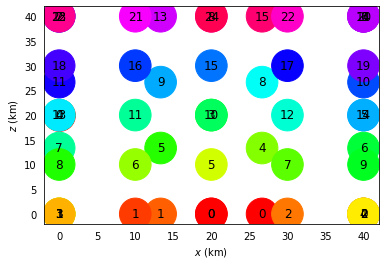

In [55]:
select_list = problem_list[:5]
setups = [None for _ in select_list]
outputs = [None for _ in select_list]
dpdx_crit = 100

for i, node_list in enumerate(select_list):
  setups[i] = setup_system(node_list, dpdx_crit)
  outputs[i] = run_system(*setups[i])

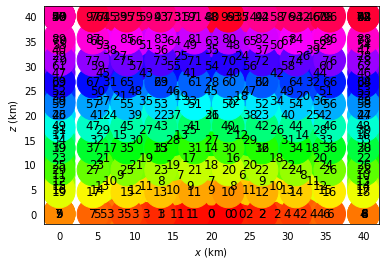

In [42]:
select_list2 = problem_list[5:10]
setups2 = [None for _ in select_list2]
outputs2 = [None for _ in select_list2]
dpdx_crit = 100

for i, node_list in enumerate(select_list2):
  setups2[i] = setup_system(node_list, dpdx_crit)
  outputs2[i] = run_system(*setups2[i])

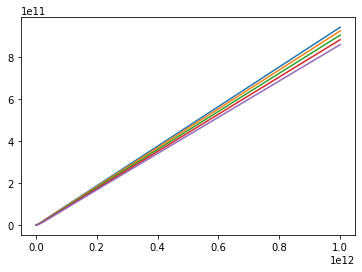

In [52]:

for i, out in enumerate(outputs2):
  # (t_vec, m, p, u, q_out, m_erupted_out, global_sys)
  _t, _m, _p, _u, _q, _m_out, _gs = out
  plt.plot(_t, _m_out);

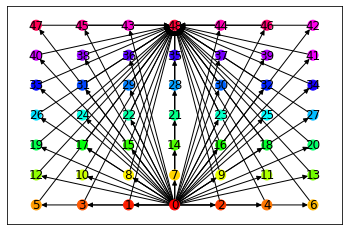

In [67]:
import networkx as nx

_t, _m, _p, _u, _q, _m_out, _gs = outputs2[1]

Y = _gs.get_connectivity(_q[-1,:])
G = nx.DiGraph(Y)
# Node index-position mapping (2D projection)
length_scale = 1e3
pos = {i:(n.x / length_scale, n.z / length_scale,)
        for (i, n) in enumerate(_gs.nodes)}
V_nodes = np.array([node.V for node in _gs.nodes])

node_scale = 100
node_size = node_scale*V_nodes/V_nodes.max()
cmap = matplotlib.cm.hsv
colors =  cmap(np.linspace(0,1,_gs.num_blocks,endpoint=False))
nx.draw_networkx(G, pos, node_size=node_size, node_color=colors,
                        edge_cmap=(0, 1), ax=plt.gca())

The first aspect of network topology that we explore is the behavior of distributing the storage capacity of a single chamber into a regular grid of smaller chambers. That is, we consider a regular grid of $N \times N$ chambers, each with an initial volume $V_0/N^2$, and consider the fluid transport problem through each grid.

In [ ]:
# np.save("outputs2_checkpoint_new", outputs2)

c:\Python39\lib\site-packages\numpy\core\_asarray.py:171: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order, subok=True)


In [11]:
loadin = np.load("outputs2_checkpoint.npy", allow_pickle=True)

In [47]:
N_x_range[5:10]

array([ 6,  7,  8,  9, 10])

In [31]:
# _t, _m, _p, _u, _q, _m_out, _gs
loadin[0][4].shape


(20000, 3744)

In [42]:
import networkx as nx

In [45]:
plot_x

0.001662526974500161

In [75]:
out_concat = [*np.array(outputs), *loadin]
N_range = np.arange(0, 10)

len(out_concat), len(N_range)

C:\Users\Fredric\AppData\Local\Temp\ipykernel_30652\2175936799.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  out_concat = [*np.array(outputs), *loadin]


(10, 10)

In [83]:
dpdx_crit_fixed = 100
# N_subrange = N_x_range[5:10]
N_subrange = N_range + 1

def conds_of(outputs):
  conds_out = [None for _ in outputs]
  for i, _sim_out in enumerate(outputs):
    _t, _m, _p, _u, _q, _m_out, _gs = _sim_out
    Y_avg = get_time_averaged_connectivity(*_sim_out, averaged=True)
    conds_out[i] = compute_undirected_st_cond(nx.Graph(Y_avg + Y_avg.T))
  return np.array(conds_out)

# cond = compute_undirected_st_cond(nx.Graph(Y_avg + Y_avg.T))\

st_conds = conds_of(out_concat[1:])

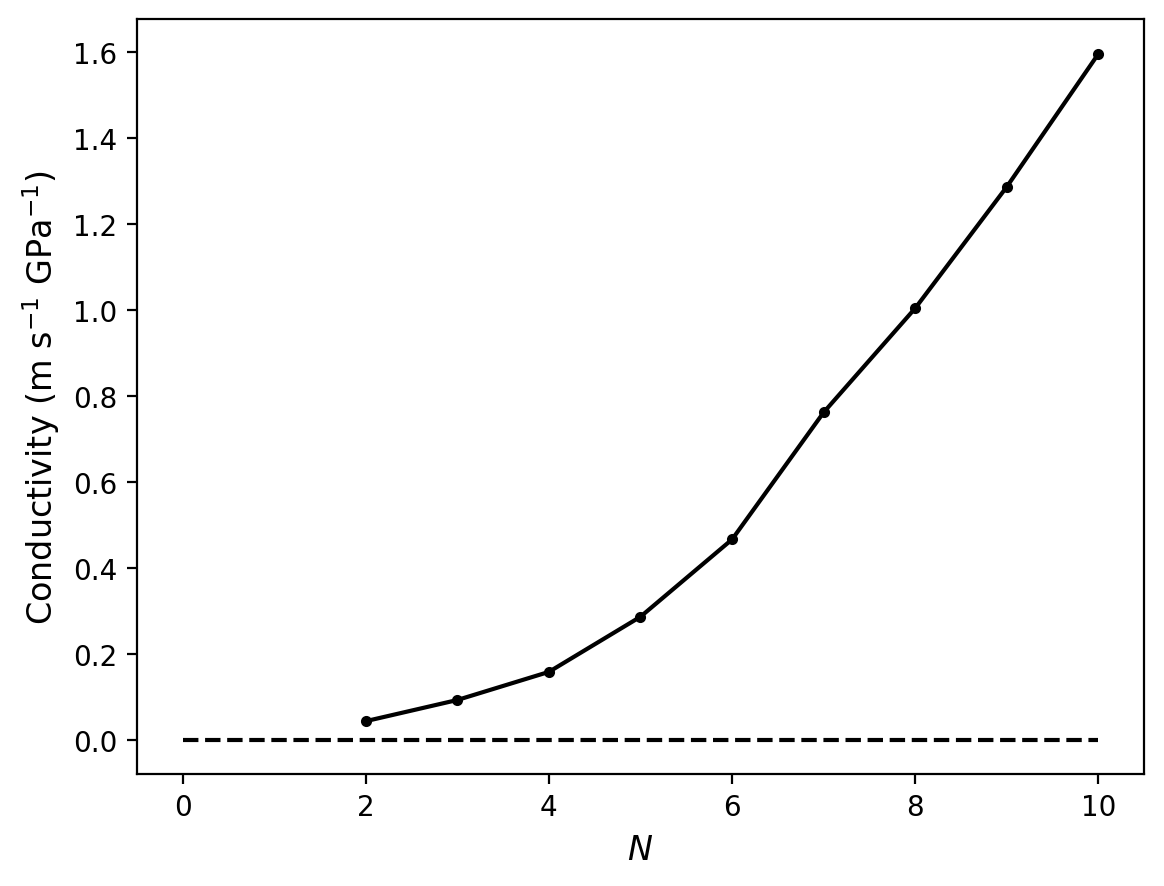

In [85]:

fig = plt.figure(figsize=(6.5,5), dpi=200)
ax = plt.gca()

# mass_rate = 1.0
# pressurization_rate = _gs.K_f * mass_rate / _gs.nodes[0].m0
# relaxation_rate = 3.0 / _gs.t_d
# plot_x = dpdx_crit_fixed * z_scale * relaxation_rate / pressurization_rate
plot_x = N_subrange[1:]

plot_y = st_conds * 1e9
plt.plot(plot_x, plot_y, 'k.-')
plt.plot([0, plot_x[-1]], [0, 0], 'k--')
# plt.xlabel("$dp/dx$ [TODO: nondimensionalization]", fontsize=12)
plt.xlabel("$N$", fontsize=12)
plt.ylabel("Conductivity (m s${}^{-1}$ GPa${}^{-1}$)", fontsize=12)

inset_width = .3
inset_height = .3
# Color of line connecting inset to data
label_line_color = [.8, .5, .6]

# # Select parameters for inset 1
# select_index = 0
# inset1_loc = [.1, .1, inset_width, inset_height]
# inset1 = ax.inset_axes(inset1_loc)
# # Draw network in inset
# draw_network_at(outputs_vary_threshold[select_index],
#                 ax=inset1, node_scale=10, with_labels=False,
#                 plot_threshold=0., arrows=False)
# # Add connecting line using mixed coordinates: (data coords and coord system of
# # inset) 
# fig.add_artist(matplotlib.patches.ConnectionPatch(
#   xyA=(plot_x[select_index], plot_y[select_index]), coordsA=ax.transData,
#   xyB=(.3, 1), coordsB=inset1.transAxes, color=label_line_color))

# # Select parameters for inset 2
# select_index = 3
# inset2_loc = [.4, .63, inset_width, inset_height]
# inset2 = ax.inset_axes(inset2_loc)
# # Draw network in inset
# draw_network_at(outputs_vary_threshold[select_index],
#                 ax=inset2, node_scale=10, with_labels=False,
#                 plot_threshold=0., arrows=False)
# # Add connecting line using mixed coordinates: (data coords and coord system of
# # inset)
# fig.add_artist(matplotlib.patches.ConnectionPatch(
#   xyA=(plot_x[select_index], plot_y[select_index]), coordsA=ax.transData,
#   xyB=(.3, 0), coordsB=inset2.transAxes, color=label_line_color))

# # Select parameters for inset 3
# select_index = 6
# inset3_loc = [.62, .2, inset_width, inset_height]
# inset3 = ax.inset_axes(inset3_loc)
# # Draw network in inset
# draw_network_at(outputs_vary_threshold[select_index],
#                 ax=inset3, node_scale=10, with_labels=False,
#                 plot_threshold=0., arrows=False)
# # Add connecting line using mixed coordinates: (data coords and coord system of
# # inset)
# fig.add_artist(matplotlib.patches.ConnectionPatch(
#   xyA=(plot_x[select_index], plot_y[select_index]), coordsA=ax.transData,
#   xyB=(.3, 0), coordsB=inset3.transAxes, color=label_line_color))


In [97]:
out_concat[0][5][-1]
[tup[5][-1] for tup in out_concat]

[988307050166.2324,
 948612173950.0541,
 965314169099.3513,
 966405414560.4824,
 956133568215.008,
 941597259509.8693,
 924113731806.4868,
 904074383323.3904,
 882192981208.8121,
 858834273589.9792]

In [ ]:
for i, out in enumerate(out_concat[1:]):
  plt.plot(out[0], out[5])

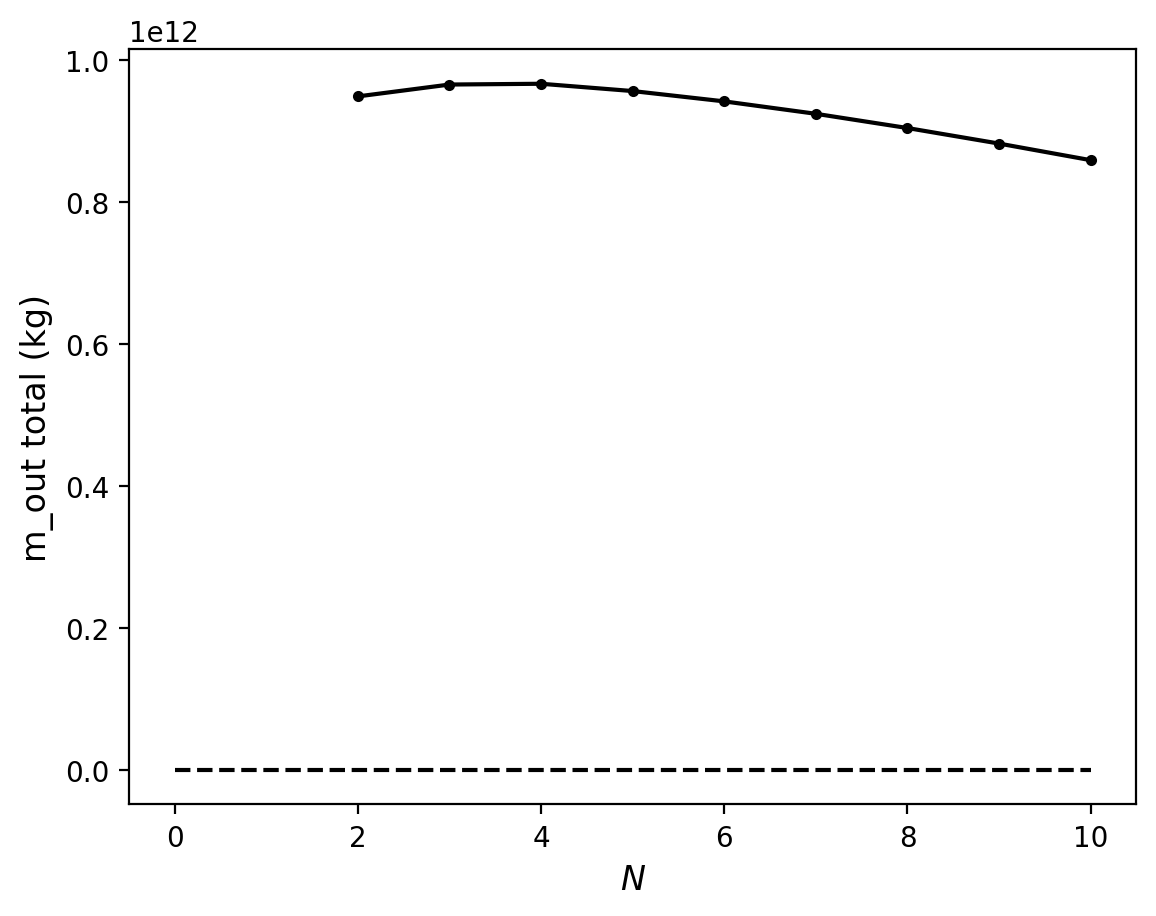

In [100]:

fig = plt.figure(figsize=(6.5,5), dpi=200)
ax = plt.gca()

# mass_rate = 1.0
# pressurization_rate = _gs.K_f * mass_rate / _gs.nodes[0].m0
# relaxation_rate = 3.0 / _gs.t_d
# plot_x = dpdx_crit_fixed * z_scale * relaxation_rate / pressurization_rate
plot_x = N_subrange[1:]

plot_y = [tup[5][-1] for tup in out_concat][1:]
plt.plot(plot_x, plot_y, 'k.-')
plt.plot([0, plot_x[-1]], [0, 0], 'k--')
# plt.xlabel("$dp/dx$ [TODO: nondimensionalization]", fontsize=12)
plt.xlabel("$N$", fontsize=12)
plt.ylabel("m_out total (kg)", fontsize=12)

inset_width = .3
inset_height = .3
# Color of line connecting inset to data
label_line_color = [.8, .5, .6]

# # Select parameters for inset 1
# select_index = 0
# inset1_loc = [.1, .1, inset_width, inset_height]
# inset1 = ax.inset_axes(inset1_loc)
# # Draw network in inset
# draw_network_at(outputs_vary_threshold[select_index],
#                 ax=inset1, node_scale=10, with_labels=False,
#                 plot_threshold=0., arrows=False)
# # Add connecting line using mixed coordinates: (data coords and coord system of
# # inset) 
# fig.add_artist(matplotlib.patches.ConnectionPatch(
#   xyA=(plot_x[select_index], plot_y[select_index]), coordsA=ax.transData,
#   xyB=(.3, 1), coordsB=inset1.transAxes, color=label_line_color))

# # Select parameters for inset 2
# select_index = 3
# inset2_loc = [.4, .63, inset_width, inset_height]
# inset2 = ax.inset_axes(inset2_loc)
# # Draw network in inset
# draw_network_at(outputs_vary_threshold[select_index],
#                 ax=inset2, node_scale=10, with_labels=False,
#                 plot_threshold=0., arrows=False)
# # Add connecting line using mixed coordinates: (data coords and coord system of
# # inset)
# fig.add_artist(matplotlib.patches.ConnectionPatch(
#   xyA=(plot_x[select_index], plot_y[select_index]), coordsA=ax.transData,
#   xyB=(.3, 0), coordsB=inset2.transAxes, color=label_line_color))

# # Select parameters for inset 3
# select_index = 6
# inset3_loc = [.62, .2, inset_width, inset_height]
# inset3 = ax.inset_axes(inset3_loc)
# # Draw network in inset
# draw_network_at(outputs_vary_threshold[select_index],
#                 ax=inset3, node_scale=10, with_labels=False,
#                 plot_threshold=0., arrows=False)
# # Add connecting line using mixed coordinates: (data coords and coord system of
# # inset)
# fig.add_artist(matplotlib.patches.ConnectionPatch(
#   xyA=(plot_x[select_index], plot_y[select_index]), coordsA=ax.transData,
#   xyB=(.3, 0), coordsB=inset3.transAxes, color=label_line_color))


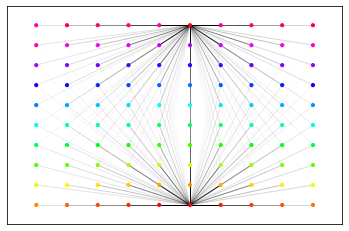

In [88]:
import networkx as nx

def draw_network_at(sim_out, ax=None, node_scale=200, with_labels=True,
                    plot_threshold=0.0, arrows=True):
  _t, _m, _p, _u, _q, _m_out, _gs = sim_out
  Y_avg = get_time_averaged_connectivity(*sim_out, averaged=True)

  Y_avg = np.where(Y_avg / Y_avg.max() > plot_threshold, Y_avg, 0.0)

  G = nx.DiGraph(Y_avg)
  # Node index-position mapping (2D projection)
  length_scale = 1e3
  pos = {i:(n.x / length_scale, n.z / length_scale,)
          for (i, n) in enumerate(_gs.nodes)}
  V_nodes = np.array([node.V for node in _gs.nodes])
  # Set node appearance
  
  node_size = node_scale*V_nodes/V_nodes.max()
  node_colors =  matplotlib.cm.hsv(np.linspace(0,1,_gs.num_blocks,endpoint=False))
  # Take averaged conductivity Y as edge intensity
  edge_intensity = (np.array(scipy.sparse.csr_matrix(Y_avg).data))
  edge_intensity /= edge_intensity.max()
  if ax is None:
    ax = plt.gca()

  # Create new colormap
  from matplotlib.colors import ListedColormap
  custom_cmap_array = np.zeros((256,4))
  custom_cmap_array[:,3] = np.linspace(0, 1 ,256)
  custom_cmap = ListedColormap(custom_cmap_array)

  nx.draw_networkx(G, pos,
                  ax=ax,
                  node_size=node_size,
                  node_color=node_colors,
                  edge_cmap=custom_cmap,
                  # edge_cmap=matplotlib.cm.Greys,
                  edge_color=edge_intensity, with_labels=with_labels, arrows=arrows)


draw_network_at(out_concat[-1], node_scale=10, with_labels=False,
                plot_threshold=0., arrows=False)

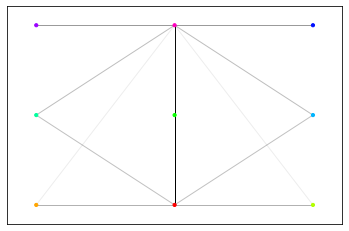

In [90]:
draw_network_at(out_concat[2], node_scale=10, with_labels=False,
                plot_threshold=0., arrows=False)

# Local/global connection

In [76]:
V_total = 1e9

# Fix N_x for 
N_x = 5

# Set square grid
N_z = N_x
# Set planar geometry (y-scale = 0)
y_scale = 0.0
# Compute total number of chambers in grid
N_chamber = N_x * N_z
# Generate chamber coordinates
z_axis = np.linspace(0, z_scale, N_z)
# Shuffle index so center node starts
_x1 = np.arange(N_x//2-1, -1, -1)
_x2 = np.arange(N_x//2, N_x, )
_ind = np.empty((N_x,), dtype=int)
_ind[::2] = _x2
_ind[1::2] = _x1
x_axis = np.linspace(0, x_scale, N_x)[_ind]

mg_x, mg_z = np.meshgrid(x_axis, z_axis)
x_nodes = mg_x.ravel()
y_nodes = y_scale * np.zeros((N_chamber,))
z_nodes = mg_z.ravel()

# Swap -1 index with the center node at the top layer
x_nodes[-1], x_nodes[-N_x] = x_nodes[-N_x], x_nodes[-1]
z_nodes[-1], z_nodes[-N_x] = z_nodes[-N_x], z_nodes[-1]

if N_z == 1:
  z_nodes[:] = 0.5 * z_scale

# Split volume among constituents
V_nodes = np.full((N_chamber,), V_total / N_chamber)

list_nodes_fixed = [MagmaChamber(x=x, y=y, z=z,
  p_setting=None, T_setting=1200, V_setting=V)
  for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

In [107]:
def setup_system_2(list_nodes, dpdx_crit):
  # Set up for timestepping later
  global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                    r_hydr=r_hydr, mu0=mu0, 
                                    rho0=2500, K_f=K_f, Nr=50,
                                    dpdx_crit=dpdx_crit,
                                    dpdx_threshold_scale=0.05 * dpdx_crit,
                                    R_outer_ratio=20,
                                    max_edge_dist=99e9)
                                    # max_edge_dist=10*node_sep)
  # Source term due to mass injection at node 0
  f_inj = global_sys.create_single_mass_injection_source(1.0)
  # Source term due to eruption at node -1
  f_erupt = global_sys.create_eruption_source(p_erupt=2.5e6, mu_erupt=1e5, r_conduit=1000)
  # Time vector
  # t_vec = np.linspace(0, 10e11, 20000)
  t_vec = np.linspace(0, 20e10, 4000)
  # Display graph
  # global_sys.show_network(global_sys.q0)
  
  return (global_sys, t_vec, f_inj, f_erupt)

In [ ]:
dpdx_crit_range = np.geomspace(1, 1e4, 8)
setups_vary_threshold = [None for _ in dpdx_crit_range]
outputs_vary_threshold = [None for _ in dpdx_crit_range]

for i, dpdx_crit in enumerate(dpdx_crit_range):
  setups_vary_threshold[i] = setup_system_2(list_nodes_fixed, dpdx_crit)
  print(f"Case {i} is set up")
  outputs_vary_threshold[i] = run_system(*setups_vary_threshold[i])
  print(f"Case {i} is complete.")

Case 0 is set up
Case 0 is complete.
Case 1 is set up
Case 1 is complete.
Case 2 is set up
Case 2 is complete.
Case 3 is set up
Case 3 is complete.
Case 4 is set up
Case 4 is complete.
Case 5 is set up
Case 5 is complete.
Case 6 is set up
Case 6 is complete.
Case 7 is set up
Case 7 is complete.


In [299]:
dpdx_crit_range2 = np.geomspace(1e-1, 1e5, 32)
setups_vary_threshold2 = [None for _ in dpdx_crit_range2]
outputs_vary_threshold2 = [None for _ in dpdx_crit_range2]

for i, dpdx_crit in enumerate(dpdx_crit_range2):
  setups_vary_threshold2[i] = setup_system_2(list_nodes_fixed, dpdx_crit)
  print(f"Case {i} is set up")
  outputs_vary_threshold2[i] = run_system(*setups_vary_threshold2[i])
  print(f"Case {i} is complete.")

Case 0 is set up
Case 0 is complete.
Case 1 is set up
Case 1 is complete.
Case 2 is set up
Case 2 is complete.
Case 3 is set up
Case 3 is complete.
Case 4 is set up
Case 4 is complete.
Case 5 is set up
Case 5 is complete.
Case 6 is set up
Case 6 is complete.
Case 7 is set up
Case 7 is complete.
Case 8 is set up
Case 8 is complete.
Case 9 is set up
Case 9 is complete.
Case 10 is set up
Case 10 is complete.
Case 11 is set up
Case 11 is complete.
Case 12 is set up
Case 12 is complete.
Case 13 is set up
Case 13 is complete.
Case 14 is set up
Case 14 is complete.
Case 15 is set up
Case 15 is complete.
Case 16 is set up
Case 16 is complete.
Case 17 is set up
Case 17 is complete.
Case 18 is set up
Case 18 is complete.
Case 19 is set up
Case 19 is complete.
Case 20 is set up
Case 20 is complete.
Case 21 is set up
Case 21 is complete.
Case 22 is set up
Case 22 is complete.
Case 23 is set up
Case 23 is complete.
Case 24 is set up
Case 24 is complete.
Case 25 is set up
Case 25 is complete.
Case 2

In [ ]:
# np.savez("checkpoint_set2",
#          outputs_vary_threshold2_copy0 = [item[0] for item in outputs_vary_threshold2_copy],
#          outputs_vary_threshold2_copy1 = [item[1] for item in outputs_vary_threshold2_copy],
#          outputs_vary_threshold2_copy2 = [item[2] for item in outputs_vary_threshold2_copy],
#          outputs_vary_threshold2_copy3 = [item[3] for item in outputs_vary_threshold2_copy],
#          outputs_vary_threshold2_copy4 = [item[4] for item in outputs_vary_threshold2_copy],
#          outputs_vary_threshold2_copy5 = [item[5] for item in outputs_vary_threshold2_copy],
#          )

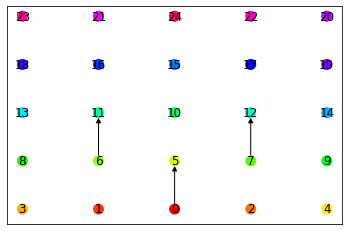

In [85]:
import networkx as nx

_t, _m, _p, _u, _q, _m_out, _gs = outputs_vary_threshold[2]

Y = _gs.get_connectivity(_q[-1,:])
G = nx.DiGraph(Y)
# Node index-position mapping (2D projection)
length_scale = 1e3
pos = {i:(n.x / length_scale, n.z / length_scale,)
        for (i, n) in enumerate(_gs.nodes)}
V_nodes = np.array([node.V for node in _gs.nodes])

node_scale = 100
node_size = node_scale*V_nodes/V_nodes.max()
cmap = matplotlib.cm.hsv
colors =  cmap(np.linspace(0,1,_gs.num_blocks,endpoint=False))
nx.draw_networkx(G, pos, node_size=node_size, node_color=colors,
                        edge_cmap=(0, 1), ax=plt.gca())

In [86]:
def get_time_averaged_connectivity(_t, _m, _p, _u, _q, _m_out, _global_sys, averaged=True):
  Nr, num_blocks, block_size = _global_sys.Nr, _global_sys.num_blocks, _global_sys.block_size

  Y = np.zeros((_t.size, num_blocks, num_blocks))

  def smoother(x, scale):
    ''' Returns one-sided compact smoothed step, such that
      1. u(x < -scale) = 0
      2. u(x >= 0) = 1.
      3. u smoothly interpolates from 0 to 1 in between.
    '''
    # Shift, scale, and clip to [-1, 0] to prevent exp overflow
    if scale != 0:
      _x = np.clip(x / scale + 1, 0, 1)
    else:
      _x = np.where(x >= 0, 1, 0)
    f0 = np.exp(-1/np.where(_x == 0, 1, _x))
    f1 = np.exp(-1/np.where(_x == 1, 1, 1-_x))
    # Return piecewise evaluation
    return np.where(_x >= 1, 1,
          np.where(_x <= 0, 0, 
          f0 / (f0 + f1)))

  for i in range(num_blocks):
    node_i = _global_sys.nodes[i]
    for j in range(num_blocks):
      if i == j:
        continue
      node_j = _global_sys.nodes[j]
      # Compute distance
      dist = np.sqrt((node_i.x - node_j.x) ** 2
                      + (node_i.y - node_j.y) ** 2
                      + (node_i.z - node_j.z) ** 2)
      if np.isclose(dist, 0.0):
        raise ValueError("Distance between chamber {i} and {j} is zero.")
      elif dist > _global_sys.max_edge_dist:
        continue
      # Compute average pressure gradient
      dpdx = (_p[:,i] - _p[:,j]) / dist
      # Resolve remote tensile stress in x-direction
      opening_stress = _global_sys.remote_sigma_xx * np.abs(node_i.z - node_j.z)/ dist
      # Effective pressure gradient
      dpdx_eff = dpdx
      # Effective critical pressure gradient for opening
      dpdx_crit_eff = _global_sys.dpdx_crit - opening_stress

      # Factor between (0, 1) that modulates flow between the two chambers
      if dpdx_crit_eff != 0:
        threshold_factor = smoother(np.abs(dpdx_eff) - dpdx_crit_eff,
                                    _global_sys.dpdx_threshold_scale) * (dpdx_eff > 0).astype(float)
        if np.any(threshold_factor > 1) or np.any(threshold_factor < 0):
          raise ValueError
      else:
        threshold_factor = np.ones_like(dpdx_eff)

      # Compute flow admittance ( (m/s) / Pa )
      Y[:,i,j] = threshold_factor * _global_sys.r_hydr * _global_sys.r_hydr / 16.0 / _global_sys.mu0 / dist

  if averaged:
    return Y.mean(axis=0)
  else:
    return Y

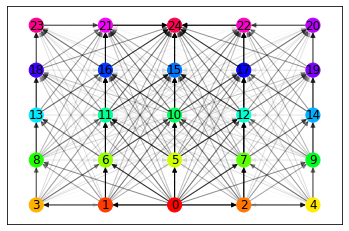

In [192]:
import networkx as nx

def draw_network_at(sim_out, ax=None, node_scale=200, with_labels=True,
                    plot_threshold=0.0, arrows=True):
  _t, _m, _p, _u, _q, _m_out, _gs = sim_out
  Y_avg = get_time_averaged_connectivity(*sim_out, averaged=True)

  Y_avg = np.where(Y_avg / Y_avg.max() > plot_threshold, Y_avg, 0.0)

  G = nx.DiGraph(Y_avg)
  # Node index-position mapping (2D projection)
  length_scale = 1e3
  pos = {i:(n.x / length_scale, n.z / length_scale,)
          for (i, n) in enumerate(_gs.nodes)}
  V_nodes = np.array([node.V for node in _gs.nodes])
  # Set node appearance
  
  node_size = node_scale*V_nodes/V_nodes.max()
  node_colors =  matplotlib.cm.hsv(np.linspace(0,1,_gs.num_blocks,endpoint=False))
  # Take averaged conductivity Y as edge intensity
  edge_intensity = (np.array(scipy.sparse.csr_matrix(Y_avg).data))
  edge_intensity /= edge_intensity.max()
  if ax is None:
    ax = plt.gca()

  # Create new colormap
  from matplotlib.colors import ListedColormap
  custom_cmap_array = np.zeros((256,4))
  custom_cmap_array[:,3] = np.linspace(0, 1 ,256)
  custom_cmap = ListedColormap(custom_cmap_array)

  nx.draw_networkx(G, pos,
                  ax=ax,
                  node_size=node_size,
                  node_color=node_colors,
                  edge_cmap=custom_cmap,
                  # edge_cmap=matplotlib.cm.Greys,
                  edge_color=edge_intensity, with_labels=with_labels, arrows=arrows)

draw_network_at(outputs_vary_threshold[0], plot_threshold=0.0)

In [38]:
def compute_undirected_st_cond(G):
  V = len(G.nodes)
  L = nx.laplacian_matrix(G)
  if not nx.has_path(G, 0, V-1):
      return 0.0
  # Construct s-t test vector
  chi = np.zeros((L.shape[0],))
  chi[0] = 1.0
  chi[-1] = -1.0

  use_dense_matrix = False
  if use_dense_matrix:
    # Compute dense pseudo inverse
    iL = scipy.linalg.pinv(L.todense())
    # Compute conductivity (reciprocal of s-t resistance)
    st_resistance = np.einsum("i, ij, j ->", chi, iL, chi)
  else:
    v, exit_code = scipy.sparse.linalg.cg(L, chi)
    if exit_code != 0:
      raise ValueError(f"scipy.sparse.linalg.cg terminated with unsuccessful exit code {exit_code}.")
    st_resistance = np.dot(chi, v)

  return 1.0 / st_resistance


In [ ]:

cond = compute_undirected_st_cond(nx.Graph(Y_avg + Y_avg.T))

In [ ]:
st_conds = [None for _ in outputs_vary_threshold]
for i, _sim_out in enumerate(outputs_vary_threshold):
  _t, _m, _p, _u, _q, _m_out, _gs = _sim_out
  Y_avg = get_time_averaged_connectivity(*_sim_out, averaged=True)
  st_conds[i] = compute_undirected_st_cond(nx.Graph(Y_avg + Y_avg.T))
st_conds = np.array(st_conds)


We define the nondimensionalized minimum pressure gradient $g^*$ allowing flow between a pair of chambers through the expression
$$
g^*
=
\left( \frac{dp}{dx} \right)_\mathrm{th} \frac{L_z}{p_\mathrm{ch}}
=
\left( \frac{dp}{dx} \right)_\mathrm{th}
L_z
\left( \frac{m_0}{\dot{m}_\mathrm{in}} \frac{1}{K_\mathrm{fluid}} \right)
\left( \frac{3 G}{\eta} \right)
.
$$
Here $(dp/dx)_\mathrm{th}$ is the threshold pressure gradient allowing flow, $L_z$ is the length scale of the chamber network, and $p_\mathrm{ch}$ is a characteristic pressure scale. We choose the spacing of the regular grid, $L_z / (N-1)$ as the length scale, and choose the pressure scale by roughly balancing the pressurization rate of the bottom chamber of the network (chamber $0$) due to mass injection and the viscous relaxation rate of the surrounding crust.


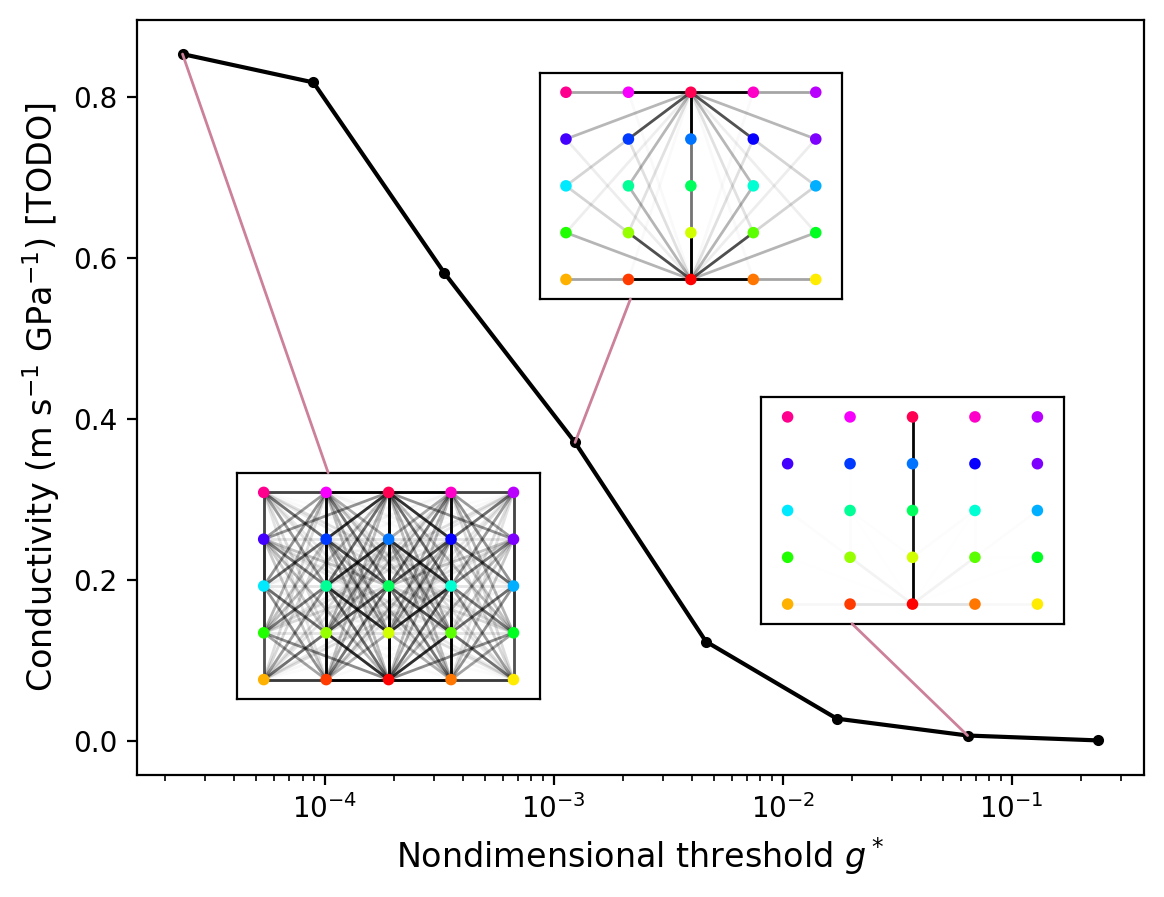

In [298]:
fig = plt.figure(figsize=(6.5,5), dpi=200)
ax = plt.gca()

mass_rate = 1.0

_gs = outputs_vary_threshold[0][6]
pressurization_rate = _gs.K_f * mass_rate / _gs.nodes[0].m0
relaxation_rate = 3.0 / _gs.t_d
plot_x = dpdx_crit_range * z_scale * relaxation_rate / pressurization_rate

plot_y = st_conds * 1e9
plt.semilogx(plot_x, plot_y, 'k.-')
# plt.xlabel("$dp/dx$ [TODO: nondimensionalization]", fontsize=12)
plt.xlabel("Nondimensional threshold $g^*$", fontsize=12)
plt.ylabel("Conductivity (m s${}^{-1}$ GPa${}^{-1}$) [TODO]", fontsize=12)

inset_width = .3
inset_height = .3
# Color of line connecting inset to data
label_line_color = [.8, .5, .6]

# Select parameters for inset 1
select_index = 0
inset1_loc = [.1, .1, inset_width, inset_height]
inset1 = ax.inset_axes(inset1_loc)
# Draw network in inset
draw_network_at(outputs_vary_threshold[select_index],
                ax=inset1, node_scale=10, with_labels=False,
                plot_threshold=0., arrows=False)
# Add connecting line using mixed coordinates: (data coords and coord system of
# inset) 
fig.add_artist(matplotlib.patches.ConnectionPatch(
  xyA=(plot_x[select_index], plot_y[select_index]), coordsA=ax.transData,
  xyB=(.3, 1), coordsB=inset1.transAxes, color=label_line_color))

# Select parameters for inset 2
select_index = 3
inset2_loc = [.4, .63, inset_width, inset_height]
inset2 = ax.inset_axes(inset2_loc)
# Draw network in inset
draw_network_at(outputs_vary_threshold[select_index],
                ax=inset2, node_scale=10, with_labels=False,
                plot_threshold=0., arrows=False)
# Add connecting line using mixed coordinates: (data coords and coord system of
# inset)
fig.add_artist(matplotlib.patches.ConnectionPatch(
  xyA=(plot_x[select_index], plot_y[select_index]), coordsA=ax.transData,
  xyB=(.3, 0), coordsB=inset2.transAxes, color=label_line_color))

# Select parameters for inset 3
select_index = 6
inset3_loc = [.62, .2, inset_width, inset_height]
inset3 = ax.inset_axes(inset3_loc)
# Draw network in inset
draw_network_at(outputs_vary_threshold[select_index],
                ax=inset3, node_scale=10, with_labels=False,
                plot_threshold=0., arrows=False)
# Add connecting line using mixed coordinates: (data coords and coord system of
# inset)
fig.add_artist(matplotlib.patches.ConnectionPatch(
  xyA=(plot_x[select_index], plot_y[select_index]), coordsA=ax.transData,
  xyB=(.3, 0), coordsB=inset3.transAxes, color=label_line_color))


Two-chamber line

In [247]:
V_total = 1e9

list_nodes_single_dike = [
  MagmaChamber(x=0, y=0, z=0,
    p_setting=None, T_setting=1200, V_setting=V_total/2),
  MagmaChamber(x=0, y=0, z=z_scale,
    p_setting=None, T_setting=1200, V_setting=V_total/2),]

In [248]:
dpdx_crit_range_single_dike = np.geomspace(1, 1e4, 8)
setups_vary_threshold_single_dike = [None for _ in dpdx_crit_range_single_dike]
outputs_vary_threshold_single_dike = [None for _ in dpdx_crit_range_single_dike]

for i, dpdx_crit in enumerate(dpdx_crit_range_single_dike):
  setups_vary_threshold_single_dike[i] = setup_system_2(list_nodes_single_dike, dpdx_crit)
  print(f"Case {i} is set up")
  outputs_vary_threshold_single_dike[i] = run_system(*setups_vary_threshold_single_dike[i])
  print(f"Case {i} is complete.")

Case 0 is set up
Case 0 is complete.
Case 1 is set up
Case 1 is complete.
Case 2 is set up
Case 2 is complete.
Case 3 is set up
Case 3 is complete.
Case 4 is set up
Case 4 is complete.
Case 5 is set up
Case 5 is complete.
Case 6 is set up
Case 6 is complete.
Case 7 is set up
Case 7 is complete.


In [249]:
st_conds_single_dike = [None for _ in outputs_vary_threshold_single_dike]
for i, _sim_out in enumerate(outputs_vary_threshold_single_dike):
  _t, _m, _p, _u, _q, _m_out, _gs = _sim_out
  Y_avg = get_time_averaged_connectivity(*_sim_out, averaged=True)
  st_conds_single_dike[i] = compute_undirected_st_cond(nx.Graph(Y_avg + Y_avg.T))
st_conds_single_dike = np.array(st_conds_single_dike)


In [ ]:
dpdx_crit_range_single_dike2 = np.geomspace(1, 1e5, 64)
setups_vary_threshold_single_dike2 = [None for _ in dpdx_crit_range_single_dike2]
outputs_vary_threshold_single_dike2 = [None for _ in dpdx_crit_range_single_dike2]

for i, dpdx_crit in enumerate(dpdx_crit_range_single_dike2):
  setups_vary_threshold_single_dike2[i] = setup_system_2(list_nodes_single_dike, dpdx_crit)
  outputs_vary_threshold_single_dike2[i] = run_system(*setups_vary_threshold_single_dike2[i])

st_conds_single_dike2 = [None for _ in outputs_vary_threshold_single_dike2]
for i, _sim_out in enumerate(outputs_vary_threshold_single_dike2):
  _t, _m, _p, _u, _q, _m_out, _gs = _sim_out
  Y_avg = get_time_averaged_connectivity(*_sim_out, averaged=True)
  st_conds_single_dike2[i] = compute_undirected_st_cond(nx.Graph(Y_avg + Y_avg.T))
st_conds_single_dike2 = np.array(st_conds_single_dike2)


In [292]:
# mass_rate = 1.0
# pressurization_rate = _gs.K_f * mass_rate / _gs.nodes[0].m0
# relaxation_rate = 3.0 / _gs.t_d
# plt.semilogx(dpdx_crit_range_single_dike2 * z_scale * relaxation_rate / pressurization_rate,
#              st_conds_single_dike2, 'k.-')

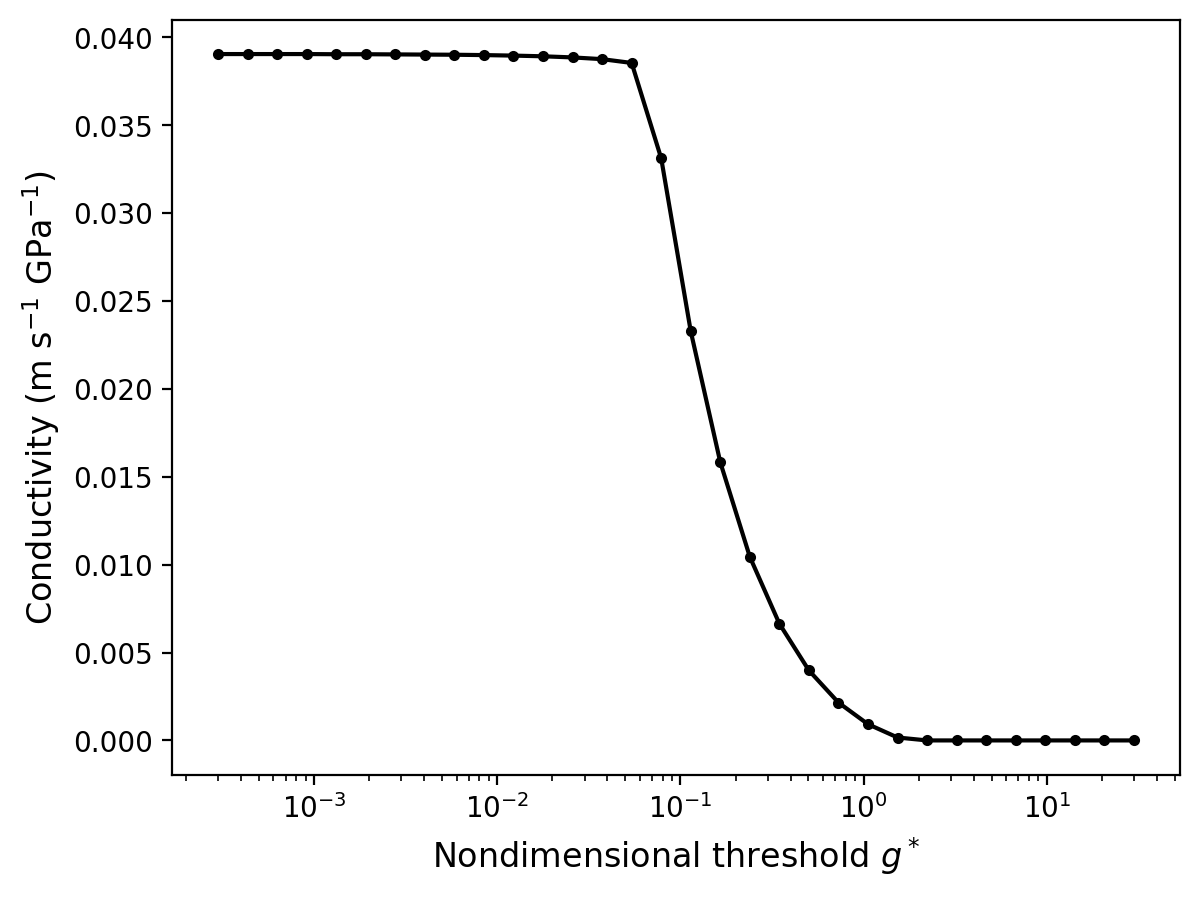

In [297]:
fig = plt.figure(figsize=(6.5,5), dpi=200)
ax = plt.gca()

mass_rate = 1.0

_gs = outputs_vary_threshold_single_dike2[0][6]
pressurization_rate = _gs.K_f * mass_rate / _gs.nodes[0].m0
relaxation_rate = 3.0 / _gs.t_d
plot_x = dpdx_crit_range_single_dike2 * z_scale * relaxation_rate / pressurization_rate

plot_y = st_conds_single_dike2 * 1e9
plt.semilogx(plot_x, plot_y, 'k.-')
plt.xlabel("Nondimensional threshold $g^*$", fontsize=12)
plt.ylabel("Conductivity (m s${}^{-1}$ GPa${}^{-1}$)", fontsize=12)

inset_width = .3
inset_height = .3
# Color of line connecting inset to data
label_line_color = [.8, .5, .6]

if False:
  # Select parameters for inset 1
  select_index = 0
  inset1_loc = [.1, .1, inset_width, inset_height]
  inset1 = ax.inset_axes(inset1_loc)
  # Draw network in inset
  draw_network_at(outputs_vary_threshold_single_dike2[select_index],
                  ax=inset1, node_scale=10, with_labels=False,
                  plot_threshold=0., arrows=False)
  # Add connecting line using mixed coordinates: (data coords and coord system of
  # inset) 
  fig.add_artist(matplotlib.patches.ConnectionPatch(
    xyA=(plot_x[select_index], plot_y[select_index]), coordsA=ax.transData,
    xyB=(.3, 1), coordsB=inset1.transAxes, color=label_line_color))

  # Select parameters for inset 2
  select_index = 3
  inset2_loc = [.4, .63, inset_width, inset_height]
  inset2 = ax.inset_axes(inset2_loc)
  # Draw network in inset
  draw_network_at(outputs_vary_threshold_single_dike2[select_index],
                  ax=inset2, node_scale=10, with_labels=False,
                  plot_threshold=0., arrows=False)
  # Add connecting line using mixed coordinates: (data coords and coord system of
  # inset)
  fig.add_artist(matplotlib.patches.ConnectionPatch(
    xyA=(plot_x[select_index], plot_y[select_index]), coordsA=ax.transData,
    xyB=(.3, 0), coordsB=inset2.transAxes, color=label_line_color))

  # Select parameters for inset 3
  select_index = 6
  inset3_loc = [.62, .2, inset_width, inset_height]
  inset3 = ax.inset_axes(inset3_loc)
  # Draw network in inset
  draw_network_at(outputs_vary_threshold_single_dike2[select_index],
                  ax=inset3, node_scale=10, with_labels=False,
                  plot_threshold=0., arrows=False)
  # Add connecting line using mixed coordinates: (data coords and coord system of
  # inset)
  fig.add_artist(matplotlib.patches.ConnectionPatch(
    xyA=(plot_x[select_index], plot_y[select_index]), coordsA=ax.transData,
    xyB=(.3, 0), coordsB=inset3.transAxes, color=label_line_color))


In [ ]:
_gs.create_single_pressure_injection_source(10e6)

TypeError: create_single_pressure_injection_source() missing 1 required positional argument: 'feed_overpressure'

In [342]:
def setup_system_3p(list_nodes, dpdx_crit):
  # Set up for timestepping later
  global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                    r_hydr=r_hydr, mu0=mu0, 
                                    rho0=2500, K_f=K_f, Nr=50,
                                    dpdx_crit=dpdx_crit,
                                    dpdx_threshold_scale=0.05 * dpdx_crit,
                                    R_outer_ratio=20,
                                    max_edge_dist=99e9)
                                    # max_edge_dist=10*node_sep)
  # Source term due to mass injection at node 0
  f_inj = global_sys.create_single_pressure_injection_source(10e6)
  # Source term due to eruption at node -1
  f_erupt = global_sys.create_eruption_source(p_erupt=2.5e6, mu_erupt=1e5, r_conduit=1000)
  # Time vector
  # t_vec = np.linspace(0, 10e11, 20000)
  t_vec = np.linspace(0, 20e10, 4000)
  # Display graph
  # global_sys.show_network(global_sys.q0)
  
  return (global_sys, t_vec, f_inj, f_erupt)

dpdx_crit_range_p = np.geomspace(1e-1, 1e5, 16)
setups_vary_threshold_p = [None for _ in dpdx_crit_range_p]
outputs_vary_threshold_p = [None for _ in dpdx_crit_range_p]

for i, dpdx_crit in enumerate(dpdx_crit_range_p):
  setups_vary_threshold_p[i] = setup_system_2(list_nodes_fixed, dpdx_crit)
  print(f"Case {i} is set up")
  outputs_vary_threshold_p[i] = run_system(*setups_vary_threshold_p[i])
  print(f"Case {i} is complete.")

Case 0 is set up
Case 0 is complete.
Case 1 is set up
Case 1 is complete.
Case 2 is set up
Case 2 is complete.
Case 3 is set up
Case 3 is complete.
Case 4 is set up
Case 4 is complete.
Case 5 is set up
Case 5 is complete.
Case 6 is set up
Case 6 is complete.
Case 7 is set up
Case 7 is complete.
Case 8 is set up
Case 8 is complete.
Case 9 is set up
Case 9 is complete.
Case 10 is set up
Case 10 is complete.
Case 11 is set up
Case 11 is complete.
Case 12 is set up
Case 12 is complete.
Case 13 is set up
Case 13 is complete.
Case 14 is set up
Case 14 is complete.
Case 15 is set up
Case 15 is complete.


In [ ]:
dpdx_crit_range_p

2

In [345]:
def conds_of(outputs):
  conds_out = [None for _ in outputs]
  for i, _sim_out in enumerate(outputs):
    _t, _m, _p, _u, _q, _m_out, _gs = _sim_out
    Y_avg = get_time_averaged_connectivity(*_sim_out, averaged=True)
    conds_out[i] = compute_undirected_st_cond(nx.Graph(Y_avg + Y_avg.T))
  return np.array(conds_out)

conds_vary_threshold_p = conds_of(outputs_vary_threshold_p)

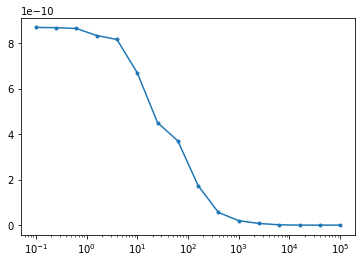

In [350]:
plt.semilogx(dpdx_crit_range_p, conds_vary_threshold_p, '.-')

In [355]:
def setup_system_4p(list_nodes, dpdx_crit):
  # Set up for timestepping later
  global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                    r_hydr=r_hydr, mu0=mu0, 
                                    rho0=2500, K_f=K_f, Nr=50,
                                    dpdx_crit=dpdx_crit,
                                    dpdx_threshold_scale=0.05 * dpdx_crit,
                                    R_outer_ratio=20,
                                    max_edge_dist=99e9)
                                    # max_edge_dist=10*node_sep)
  # Source term due to mass injection at node 0
  f_inj = global_sys.create_single_pressure_injection_source(10e6)
  # Source term due to eruption at node -1
  f_erupt = global_sys.create_eruption_source(p_erupt=2.5e6, mu_erupt=1e5, r_conduit=1000)
  # Time vector
  # t_vec = np.linspace(0, 10e11, 20000)
  t_vec = np.linspace(0, 20e10, 4000*4)
  # Display graph
  # global_sys.show_network(global_sys.q0)
  
  return (global_sys, t_vec, f_inj, f_erupt)

In [360]:
dpdx_crit_range_single_dike_p = np.geomspace(1e-1, 1e5, 32)
setups_vary_threshold_single_dike_p = [None for _ in dpdx_crit_range_single_dike_p]
outputs_vary_threshold_single_dike_p = [None for _ in dpdx_crit_range_single_dike_p]

for i, dpdx_crit in enumerate(dpdx_crit_range_single_dike_p):
  setups_vary_threshold_single_dike_p[i] = setup_system_4p(list_nodes_single_dike, dpdx_crit)
  # print(f"Case {i} is set up")
  outputs_vary_threshold_single_dike_p[i] = run_system(*setups_vary_threshold_single_dike_p[i])
  # print(f"Case {i} is complete.")

In [362]:
conds_vary_threshold_single_dike_p = conds_of(outputs_vary_threshold_single_dike_p)

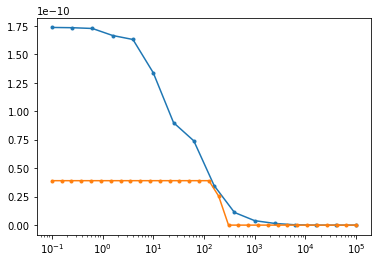

In [364]:
plt.semilogx(dpdx_crit_range_p, conds_vary_threshold_p / 5, '.-')
plt.semilogx(dpdx_crit_range_single_dike_p, conds_vary_threshold_single_dike_p, '.-')

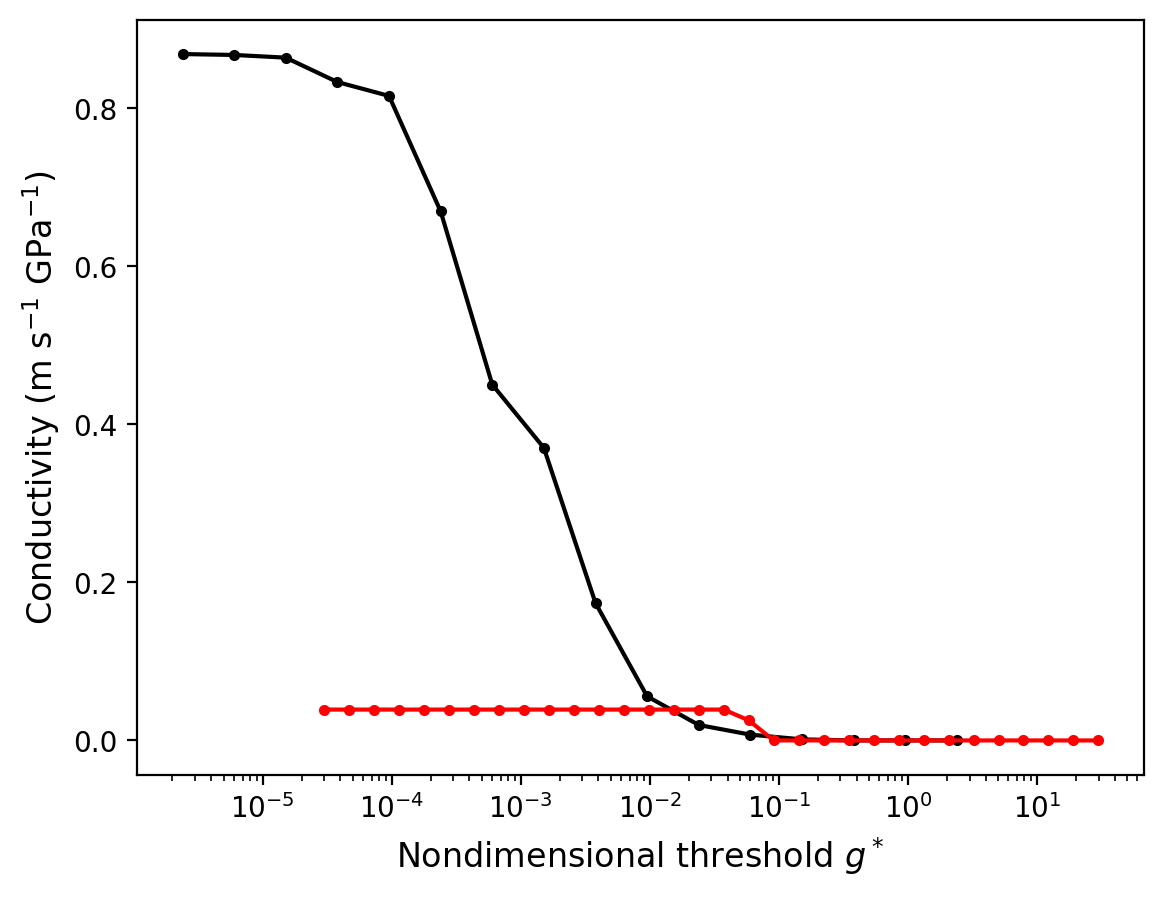

In [366]:
fig = plt.figure(figsize=(6.5,5), dpi=200)
ax = plt.gca()

mass_rate = 1.0

_gs = outputs_vary_threshold_p[0][6]
pressurization_rate = _gs.K_f * mass_rate / _gs.nodes[0].m0
relaxation_rate = 3.0 / _gs.t_d
plot_x = dpdx_crit_range_p * z_scale * relaxation_rate / pressurization_rate
plot_y = conds_vary_threshold_p * 1e9
plt.semilogx(plot_x, plot_y, 'k.-')
plt.xlabel("Nondimensional threshold $g^*$", fontsize=12)
plt.ylabel("Conductivity (m s${}^{-1}$ GPa${}^{-1}$)", fontsize=12)

_gs = outputs_vary_threshold_single_dike_p[0][6]
pressurization_rate = _gs.K_f * mass_rate / _gs.nodes[0].m0
relaxation_rate = 3.0 / _gs.t_d
plot_x = dpdx_crit_range_single_dike_p * z_scale * relaxation_rate / pressurization_rate
plot_y = conds_vary_threshold_single_dike_p * 1e9
plt.semilogx(plot_x, plot_y, 'r.-')
plt.xlabel("Nondimensional threshold $g^*$", fontsize=12)
plt.ylabel("Conductivity (m s${}^{-1}$ GPa${}^{-1}$)", fontsize=12)

inset_width = .3
inset_height = .3
# Color of line connecting inset to data
label_line_color = [.8, .5, .6]

#### Parameter exploration

In [ ]:
V_total = 1e9

def form_list(N_x):
  # Set square grid
  N_z = N_x
  # Set planar geometry (y-scale = 0)
  y_scale = 0.0
  # Compute total number of chambers in grid
  N_chamber = N_x * N_z
  # Generate chamber coordinates
  z_axis = np.linspace(0, z_scale, N_z)
  # Shuffle index so center node starts
  _x1 = np.arange(N_x//2-1, -1, -1)
  _x2 = np.arange(N_x//2, N_x, )
  _ind = np.empty((N_x,), dtype=int)
  _ind[::2] = _x2
  _ind[1::2] = _x1
  x_axis = np.linspace(0, x_scale, N_x)[_ind]

  mg_x, mg_z = np.meshgrid(x_axis, z_axis)
  x_nodes = mg_x.ravel()
  y_nodes = y_scale * np.zeros((N_chamber,))
  z_nodes = mg_z.ravel()

  # Swap -1 index with the center node at the top layer
  x_nodes[-1], x_nodes[-N_x] = x_nodes[-N_x], x_nodes[-1]
  z_nodes[-1], z_nodes[-N_x] = z_nodes[-N_x], z_nodes[-1]

  if N_z == 1:
    z_nodes[:] = 0.5 * z_scale

  # Split volume among constituents
  V_nodes = np.full((N_chamber,), V_total / N_chamber)

  list_nodes = [MagmaChamber(x=x, y=y, z=z,
    p_setting=None, T_setting=1200, V_setting=V)
    for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]
  return list_nodes

grid_N_range = [3,5,7,9]
glob_dpdx_crit_range = np.geomspace(1e-2, 1e5, 16)
glob_setups = [[None for _ in glob_dpdx_crit_range] for _ in grid_N_range]
glob_outputs = [[None for _ in glob_dpdx_crit_range] for _ in grid_N_range]

for i, N_x in enumerate(grid_N_range):
  _list_nodes = form_list(N_x)
  for j, dpdx_crit in enumerate(glob_dpdx_crit_range):
    glob_setups[i][j] = setup_system_2(_list_nodes, dpdx_crit)
    glob_outputs[i][j] = run_system(*glob_setups[i][j])
    print(f"Case {i},{j} is complete.")

Case 0,0 is complete.
Case 0,1 is complete.
Case 0,2 is complete.
Case 0,3 is complete.
Case 0,4 is complete.
Case 0,5 is complete.
Case 0,6 is complete.
Case 0,7 is complete.
Case 0,8 is complete.
Case 0,9 is complete.
Case 0,10 is complete.
Case 0,11 is complete.
Case 0,12 is complete.
Case 0,13 is complete.
Case 0,14 is complete.
Case 0,15 is complete.
Case 1,0 is complete.
Case 1,1 is complete.
Case 1,2 is complete.
Case 1,3 is complete.
Case 1,4 is complete.
Case 1,5 is complete.
Case 1,6 is complete.
Case 1,7 is complete.
Case 1,8 is complete.
Case 1,9 is complete.
Case 1,10 is complete.
Case 1,11 is complete.
Case 1,12 is complete.
Case 1,13 is complete.
Case 1,14 is complete.
Case 1,15 is complete.
Case 2,0 is complete.


Legacy

In [ ]:
# Data backup
# import os
# os.chdir("D:/")
# for i in range(len(sim_list)):
#   np.savez_compressed(f"sim_setAug1_{i}.npz",
#                       t_vec=sim_list[i][0],
#                       m=sim_list[i][1],
#                       p=sim_list[i][2],
#                       u=sim_list[i][3],
#                       q_out=sim_list[i][4],
#                       m_erupted_out=sim_list[i][5])

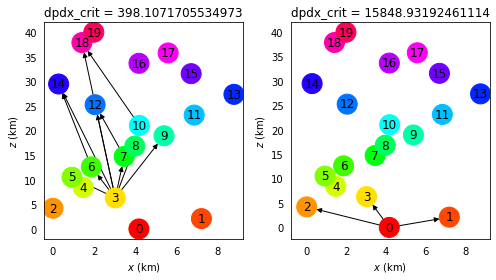

In [ ]:
plt.figure(figsize=(7,4))
plt.subplot(1,2,1)
sim_list[2][6].show_network(sim_list[2][4][-200,:], 400)
plt.title(f"dpdx_crit = {dpdx_crit_range[2]}")
plt.subplot(1,2,2)
sim_list[4][6].show_network(sim_list[4][4][-200,:], 400)
plt.title(f"dpdx_crit = {dpdx_crit_range[4]}")
plt.tight_layout()

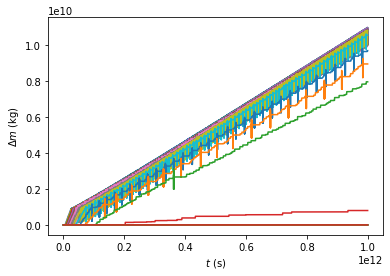

In [111]:
for i in range(24):
  plt.plot(sim_list[i][0], sim_list[i][1][:,-1] - sim_list[i][1][0,-1])
  plt.xlabel(r"$t$ (s)")
  plt.ylabel(r"$\Delta m$ (kg)")

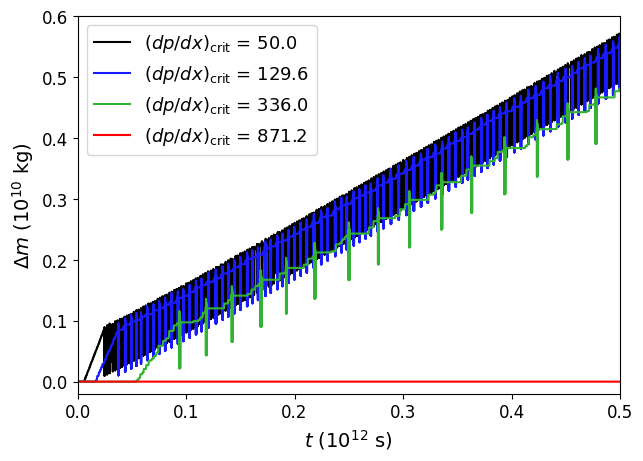

In [245]:
t_scale = 1e12
mass_scale = 1e10
line_colors = [
  [0,0,0],
  [.10,0.10,1],
  [.2,.7,.2],
  [1,0,0],
]
plt.figure(figsize=(7,5), dpi=100)
for plot_i, i in enumerate(range(0,20,5)):
  plt.plot(sim_list[i][0]/t_scale,
           (sim_list[i][1][:,-1] - sim_list[i][1][0,-1])/mass_scale,
           color=line_colors[plot_i], label=f"$(dp/dx)_\mathrm{{crit}}$ = {dpdx_crit_range[i]:.1f}")
  plt.xlabel(r"$t$ ($10^{12}$ s)", fontsize=14)
  plt.ylabel(r"$\Delta m$ ($10^{10}$ kg)", fontsize=14)
plt.gca().tick_params(axis="both", labelsize=12)
plt.xlim(0, 0.5)
plt.ylim(-0.02, .6)
plt.legend(fontsize=13)


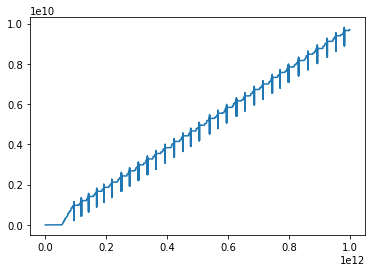

In [112]:
i = 10
plt.plot(sim_list[i][0], sim_list[i][1][:,-1] - sim_list[i][1][0,-1])

In [113]:
dpdx_crit_range[10]

336.04731786442966

In [114]:
def run_sim_acc(dpdx_crit):
  # Set up for timestepping later
  global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                    r_hydr=r_hydr, mu0=mu0, 
                                    rho0=2500, K_f=K_f, Nr=50,
                                    dpdx_crit=dpdx_crit,
                                    dpdx_threshold_scale=0.05 * dpdx_crit,
                                    R_outer_ratio=20,
                                    max_edge_dist=9e9)

  # Source term due to mass injection at node 0
  f_inj = global_sys.create_single_mass_injection_source(1.0)
  # Source term due to eruption at node -1
  f_erupt = global_sys.create_eruption_source(p_erupt=2.5e6, mu_erupt=1e5, r_conduit=1000)

  t_vec = np.linspace(0, 10e11, 40000)
  q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt)
  m, p, u = global_sys.compute_m_p_u(q_out)

  return (t_vec, m, p, u, q_out, m_erupted_out, global_sys)

sim_acc = run_sim_acc(dpdx_crit_range[10])

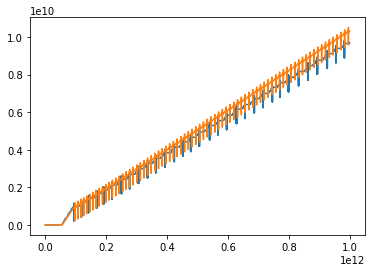

In [115]:
plt.plot(sim_list[i][0], sim_list[i][1][:,-1] - sim_list[i][1][0,-1])
plt.plot(sim_acc[0], sim_acc[1][:,-1] - sim_acc[1][0,-1])


(200000000000.0, 400000000000.0)

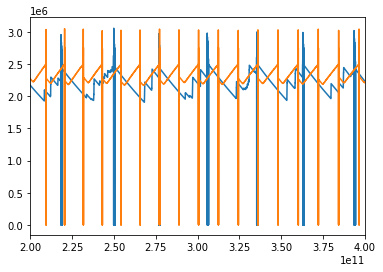

In [117]:
plt.plot(sim_list[i][0], sim_list[i][2][:,-1] - sim_list[i][2][0,-1])
plt.plot(sim_acc[0], sim_acc[2][:,-1] - sim_acc[2][0,-1])
plt.xlim(.2e12,.4e12)

In [123]:
# (t_vec, m, p, u, q_out, m_erupted_out, global_sys)
_t, _m, _p, _u, _q, _m, _global_sys = sim_acc
# Get system size information
Nr, num_blocks, block_size = _global_sys.Nr, _global_sys.num_blocks, _global_sys.block_size

In [37]:
def get_time_averaged_connectivity(_t, _m, _p, _u, _q, _m_out, _global_sys, averaged=True):
  Nr, num_blocks, block_size = _global_sys.Nr, _global_sys.num_blocks, _global_sys.block_size

  Y = np.zeros((_t.size, num_blocks, num_blocks))

  def smoother(x, scale):
    ''' Returns one-sided compact smoothed step, such that
      1. u(x < -scale) = 0
      2. u(x >= 0) = 1.
      3. u smoothly interpolates from 0 to 1 in between.
    '''
    # Shift, scale, and clip to [-1, 0] to prevent exp overflow
    if scale != 0:
      _x = np.clip(x / scale + 1, 0, 1)
    else:
      _x = np.where(x >= 0, 1, 0)
    f0 = np.exp(-1/np.where(_x == 0, 1, _x))
    f1 = np.exp(-1/np.where(_x == 1, 1, 1-_x))
    # Return piecewise evaluation
    return np.where(_x >= 1, 1,
          np.where(_x <= 0, 0, 
          f0 / (f0 + f1)))

  for i in range(num_blocks):
    node_i = _global_sys.nodes[i]
    for j in range(num_blocks):
      if i == j:
        continue
      node_j = _global_sys.nodes[j]
      # Compute distance
      dist = np.sqrt((node_i.x - node_j.x) ** 2
                      + (node_i.y - node_j.y) ** 2
                      + (node_i.z - node_j.z) ** 2)
      if np.isclose(dist, 0.0):
        raise ValueError("Distance between chamber {i} and {j} is zero.")
      elif dist > _global_sys.max_edge_dist:
        continue
      # Compute average pressure gradient
      dpdx = (_p[:,i] - _p[:,j]) / dist
      # Resolve remote tensile stress in x-direction
      opening_stress = _global_sys.remote_sigma_xx * np.abs(node_i.z - node_j.z)/ dist
      # Effective pressure gradient
      dpdx_eff = dpdx
      # Effective critical pressure gradient for opening
      dpdx_crit_eff = _global_sys.dpdx_crit - opening_stress

      # Factor between (0, 1) that modulates flow between the two chambers
      if dpdx_crit_eff != 0:
        threshold_factor = smoother(np.abs(dpdx_eff) - dpdx_crit_eff,
                                    _global_sys.dpdx_threshold_scale) * (dpdx_eff > 0).astype(float)
        if np.any(threshold_factor > 1) or np.any(threshold_factor < 0):
          raise ValueError
      else:
        threshold_factor = np.ones_like(dpdx_eff)

      # Compute flow admittance ( (m/s) / Pa )
      Y[:,i,j] = threshold_factor * _global_sys.r_hydr * _global_sys.r_hydr / 16.0 / _global_sys.mu0 / dist

  if averaged:
    return Y.mean(axis=0)
  else:
    return Y

In [193]:
np.linalg.norm(get_time_averaged_connectivity(*sim_acc) - Y_time_averaged)

0.0

Text(0.5, 1.0, '$(dp/dx)_\\mathrm{crit}$ = 2259 Pa / m')

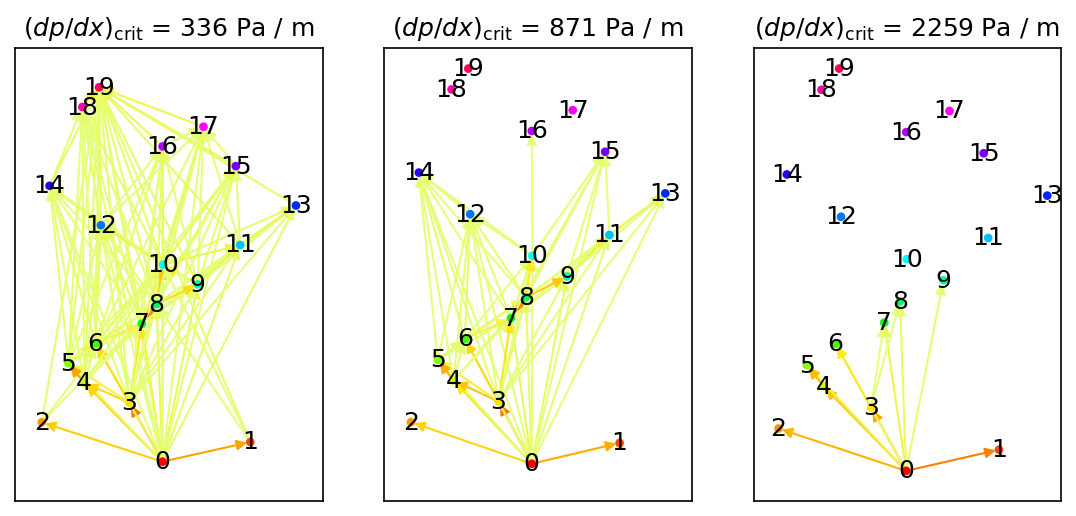

In [210]:
import networkx as nx

def shadow_plot(sim:tuple):
  # Scaled edge connectivity
  Y_time_averaged = get_time_averaged_connectivity(*sim)
  edge_intensity = (np.array(scipy.sparse.csr_matrix(Y_time_averaged).data))
  edge_intensity /= edge_intensity.max()
  edge_intensity **= 0.8
  G = nx.DiGraph(Y_time_averaged)

  # Node index-position mapping (2D projection)
  length_scale = 1e3
  pos = {i:(n.x / length_scale, n.z / length_scale,)
         for (i, n) in enumerate(_global_sys.nodes)}
  V_nodes = np.array([node.V for node in _global_sys.nodes])
  node_scale = 10
  colors = matplotlib.cm.hsv(np.linspace(0,1,num_blocks,endpoint=False))
  node_size = node_scale*V_nodes/V_nodes.max()

  
  nx.draw_networkx(G, pos, node_size=node_size, node_color=colors,
          edge_cmap=matplotlib.cm.Wistia,
          edge_color=edge_intensity)
  
plt.figure(figsize=(9,4), dpi=150)
plt.subplot(1,3,1)
shadow_plot(sim_list[10])
plt.title(rf"$(dp/dx)_\mathrm{{crit}}$ = {dpdx_crit_range[10]:.0f} Pa / m")
plt.subplot(1,3,2)
shadow_plot(sim_list[15])
plt.title(rf"$(dp/dx)_\mathrm{{crit}}$ = {dpdx_crit_range[15]:.0f} Pa / m")
plt.subplot(1,3,3)
shadow_plot(sim_list[20])
plt.title(rf"$(dp/dx)_\mathrm{{crit}}$ = {dpdx_crit_range[20]:.0f} Pa / m")


[(15, 17), (15, 19), (16, 17), (16, 19), (17, 19), (18, 19)]

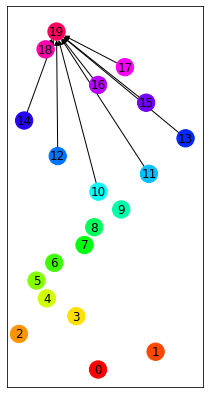

In [332]:
plt.figure(figsize=(3.5,7))
_t, _m, _p, _u, _q, _m_out, _global_sys = sim_list[10]


# Scaled edge connectivity
Y_time_averaged = get_time_averaged_connectivity(*sim_list[10])

G = nx.DiGraph(Y_time_averaged)

# Node index-position mapping (2D projection)
length_scale = 1e3
pos = {i:(n.x / length_scale, n.z / length_scale,)
        for (i, n) in enumerate(_global_sys.nodes)}
V_nodes = np.array([node.V for node in _global_sys.nodes])
node_scale = 300
colors = matplotlib.cm.hsv(np.linspace(0,1,num_blocks,endpoint=False))
node_size = node_scale*V_nodes/V_nodes.max()

node_colors = matplotlib.cm.hsv(np.linspace(0,1,_global_sys.num_blocks,endpoint=False))
# Filter edges with average conductivity at least 10% of the edge with the max
Y_time_averaged_cut = (Y_time_averaged[:,-1] > 0.1 * Y_time_averaged[:,-1].max()
                       ).astype(float)[:,np.newaxis] * Y_time_averaged
Y_time_averaged_cut[:,:-1] = 0
nx.draw_networkx(G, pos, node_size=node_size, node_color=colors,
                 edgelist=list(nx.DiGraph(Y_time_averaged_cut).edges()))

(0.0, 0.5)

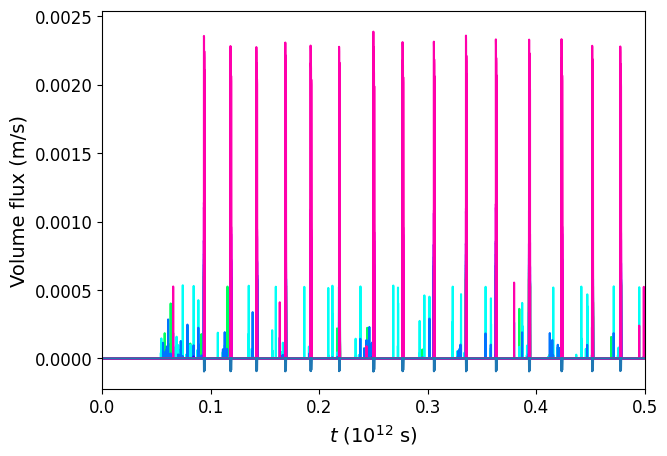

In [ ]:
# Interrogate chamber -1, flow rates in and out
line_colors = [
  [0,0,0],
  [.10,0.10,1],
  [.2,.7,.2],
  [1,0,0],
]
Y = get_time_averaged_connectivity(*sim_list[10], averaged=False)
_t, _m, _p, _u, _q, _m_out, _global_sys = sim_list[10]
# Compute volume flow rate to chamber #-1
u_in = Y[:,:,-1] * (_p[:,:] - _p[:,-1:])

t_scale = 1e12

plt.figure(figsize=(7,5), dpi=100)
for i in range(u_in.shape[1]):
  plt.plot(_t/t_scale, u_in[:,i] * _global_sys.rho0 * np.pi * _global_sys.r_hydr**2, color=node_colors[i])
plt.xlim(.2e12, .3e12)

plt.plot(0.5*(_t[1:] + _t[:-1]) / t_scale,
         -np.diff(_m_out) / np.diff(_t) / (np.pi * _global_sys.r_hydr**2 * _global_sys.rho0))


plt.xlabel(r"$t$ ($10^{12}$ s)", fontsize=14)
plt.ylabel(r"Mass rate (kg/s)", fontsize=14)
plt.gca().tick_params(axis="both", labelsize=12)
plt.xlim(0, 0.5)

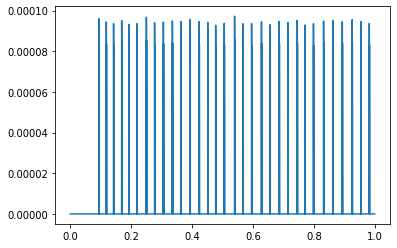

Single

In [22]:
t_vec = np.linspace(0, 5e11, 10000)
q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt)

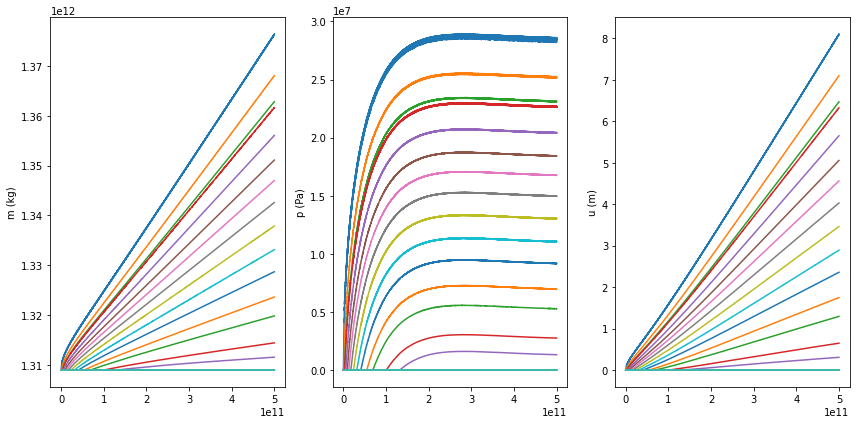

In [24]:
m, p, u = global_sys.compute_m_p_u(q_out)
fig, ax = plt.subplots(1, 3, figsize=(12,6))

max_plot_index = -1
ax[0].plot(t_vec[:max_plot_index], m[:max_plot_index])
ax[1].plot(t_vec[:max_plot_index], p[:max_plot_index])
ax[2].plot(t_vec[:max_plot_index], u[:max_plot_index])

ax[0].set_ylabel("m (kg)")
ax[1].set_ylabel("p (Pa)")
ax[2].set_ylabel("u (m)")
fig.tight_layout()

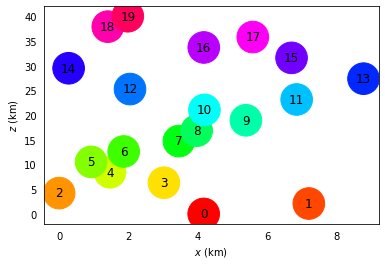

In [ ]:
q_out.shape
global_sys.show_network(global_sys.q0[:,-1],)


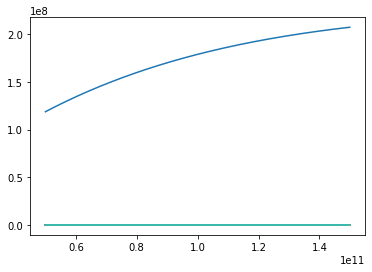

In [17]:
max_plot_index = 1000
plt.plot(t_vec[1000:3000], p[1000:3000])


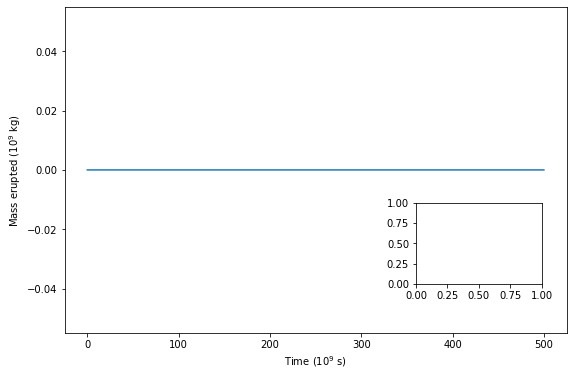

In [18]:
plt.figure(figsize=(9,6))
plt.plot(t_vec/1e9, m_erupted_out/1e9)
plt.xlabel("Time ($10^9$ s)")
plt.ylabel("Mass erupted ($10^9$ kg)")

axin1 = plt.gca().inset_axes([0.7, 0.15, 0.25, 0.25])

# axin2 = plt.gca().inset_axes([5, 7, 2.3, 2.3], transform=ax.transData)

(60.0, 70.0)

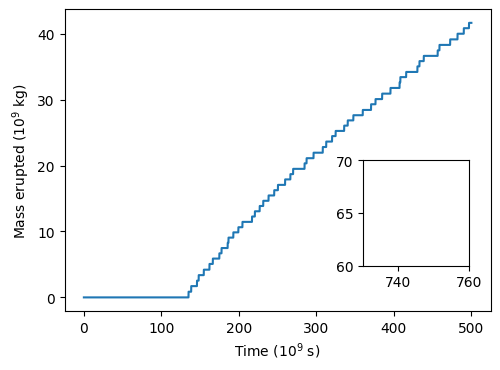

In [12]:
plt.figure(figsize=(5.5,4), dpi=100)
plt.plot(t_vec/1e9, m_erupted_out/1e9)
plt.xlabel("Time ($10^9$ s)")
plt.ylabel("Mass erupted ($10^9$ kg)")

inset_axes = plt.gca().inset_axes([0.7, 0.15, 0.25, 0.35])
inset_axes.plot(t_vec/1e9, m_erupted_out/1e9, '.-')
inset_axes.set_xlim(730,760)
inset_axes.set_ylim(60,70)


Text(0, 0.5, '$\\Delta t/dt$')

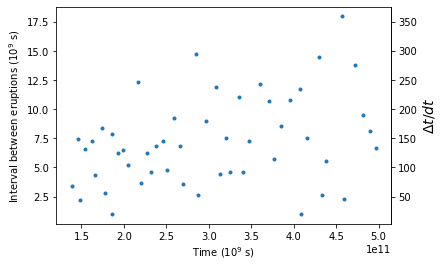

In [13]:

# Binarize eruption rates
is_erupting = np.diff(m_erupted_out) > 0
# Interval-centered times
t_vec_centered = 0.5*(t_vec[1:] + t_vec[:-1])

# Time picks for eruptions
t_eruptions = t_vec_centered[is_erupting]
# Inter-eruption intervals
t_eruption_intervals = np.diff(t_eruptions)

plt.plot(t_eruptions[1:], t_eruption_intervals/1e9, '.')
plt.xlabel("Time ($10^9$ s)")
plt.ylabel("Interval between eruptions ($10^9$ s)")
# Estimate dpdt
dt = t_vec[1] - t_vec[0]
ax2y = plt.gca().secondary_yaxis('right', functions=(
  lambda t: 1e9 * t / dt,
  lambda tau: tau * dt / 1e9))
ax2y.set_ylabel('$\Delta t/dt$', fontsize=14)

#### Melt focusing

#### Testing

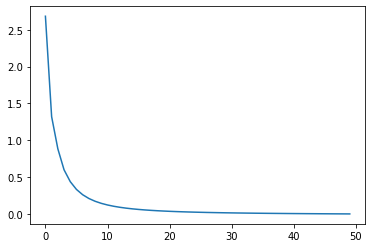

In [27]:
# Pick sample q for testing
q = q_out[-1,:]
# Extract state vector q for top node
q_loc = q[(global_sys.num_blocks-1) * global_sys.block_size:
          global_sys.num_blocks * global_sys.block_size]
# Compute max discharge from pressure
top_node = global_sys.nodes[-1]
# Compute displacement field for top node
u = (top_node.H @ q_loc + top_node.k.ravel())
plt.plot(u)

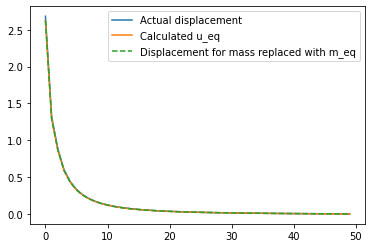

In [28]:
''' Compute displacement field after instantaneous depressurization to p0
and associated residual mass.'''

# Outer product matrix representing effect of mass on bdry displacement
outer = scipy.sparse.lil_matrix((global_sys.Nr, global_sys.Nr,))
outer[:,0] = 3 * top_node.m0 / top_node.R0 * top_node.H[:,global_sys.data_slice["mass"]]
# Compute operator q -> m_equilibrium, with the form m_eq = H_mod @ q + k_mod
H_mod = scipy.sparse.linalg.spsolve_triangular(
  scipy.sparse.eye(global_sys.Nr, global_sys.Nr) - outer,
  top_node.H.todense(),
  lower=True)
# Compute modified k
k_mod =  scipy.sparse.linalg.spsolve_triangular(
  scipy.sparse.eye(global_sys.Nr, global_sys.Nr) - outer,
  top_node.k,
  lower=True)
# Move dependence on mass in input q to dependence on m0
k_mod += H_mod[:, global_sys.data_slice["mass"]] * top_node.m0
H_mod[:, global_sys.data_slice["mass"]] = 0
# Finalize types of H, k
H_mod = scipy.sparse.csr_matrix(H_mod)
# k_mod = k_mod.toarray()

plt.plot((top_node.H @ q_loc).ravel() + (top_node.k).ravel())
plt.plot((H_mod @ q_loc).ravel() + (k_mod).ravel())

# Compute elastic equilibrium
u_eq = H_mod @ q_loc + k_mod.squeeze()
m_eq = top_node.m0 * (1 + 3 * u_eq[0] / top_node.R0)

# Test a vector where the mass is replaced by the equilibrium mass
q_test = q_loc.copy()
q_test[global_sys.data_slice["mass"]] = m_eq
u_test = top_node.H @ q_test + top_node.k.squeeze()
plt.plot(u_test, '--')

plt.legend([
  "Actual displacement",
  "Calculated u_eq",
  "Displacement for mass replaced with m_eq",
])